<a href="https://colab.research.google.com/github/kishoredage/letter_recognizer/blob/main/RF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [98]:
import pandas as pd
import matplotlib.pyplot as plt


In [99]:
df = pd.read_csv('/content/Titanic.csv')

In [100]:
df

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked,Survived
0,1,3,Allison Hill,male,17,4,2,43d75413-a939-4bd1-a516-b0d47d3572cc,144.08,Q,1
1,2,1,Noah Rhodes,male,60,2,2,6334fa2a-8b4b-47e7-a451-5ae01754bf08,249.04,S,0
2,3,3,Angie Henderson,male,64,0,0,61a66444-e2af-4629-9efb-336e2f546033,50.31,Q,1
3,4,3,Daniel Wagner,male,35,4,0,0b6c03c8-721e-4419-afc3-e6495e911b91,235.20,C,1
4,5,1,Cristian Santos,female,70,0,3,436e3c49-770e-49db-b092-d40143675d58,160.17,C,1
...,...,...,...,...,...,...,...,...,...,...,...
995,996,2,Brittany Ward,male,69,2,3,75eb0e8f-a090-460d-a7c7-655a7b434a72,19.87,Q,1
996,997,2,Edward Stanley,female,61,4,4,e55b93ad-8976-4471-9d7f-57d1e45def26,85.35,C,0
997,998,3,Christina Johnson,male,10,4,1,d06d3943-c8b3-415e-b664-704355c9bf0f,444.22,C,0
998,999,3,Edgar Miller,male,50,3,2,0e5779ec-be1a-470f-ad83-a4c869f8d3e4,234.67,S,1


In [101]:
df.isnull().sum().sum()

np.int64(0)

In [102]:
df.duplicated().sum()

np.int64(0)

In [103]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1000 non-null   int64  
 1   Pclass       1000 non-null   int64  
 2   Name         1000 non-null   object 
 3   Sex          1000 non-null   object 
 4   Age          1000 non-null   int64  
 5   SibSp        1000 non-null   int64  
 6   Parch        1000 non-null   int64  
 7   Ticket       1000 non-null   object 
 8   Fare         1000 non-null   float64
 9   Embarked     1000 non-null   object 
 10  Survived     1000 non-null   int64  
dtypes: float64(1), int64(6), object(4)
memory usage: 86.1+ KB


In [104]:
df.columns

Index(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Embarked', 'Survived'],
      dtype='object')

In [105]:
lst = df.columns

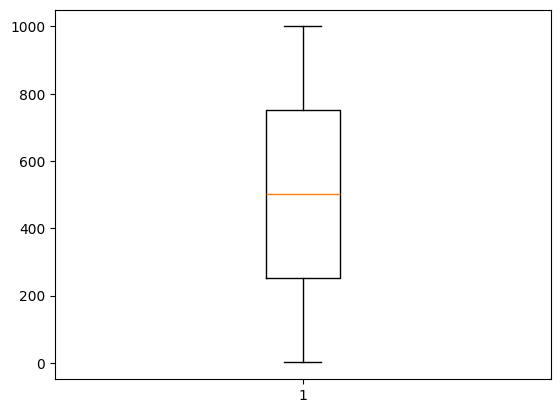

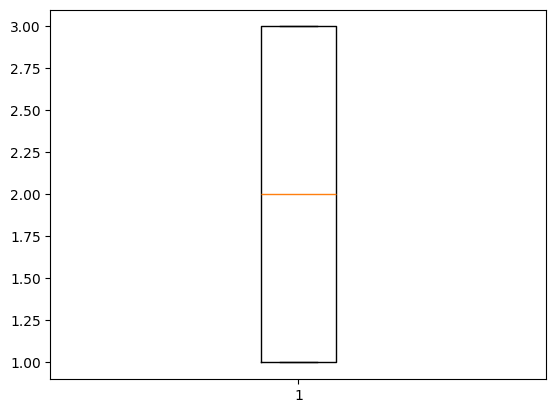

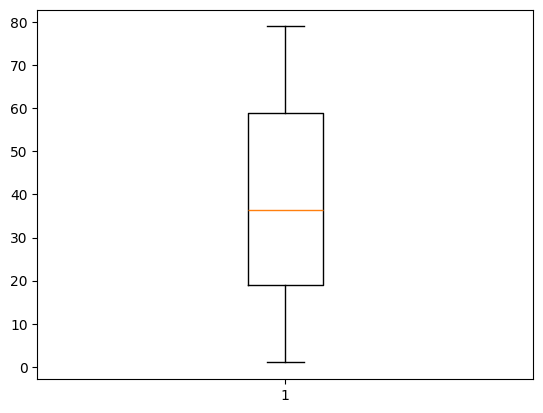

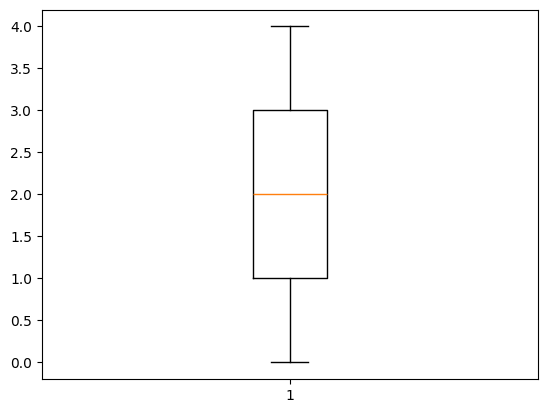

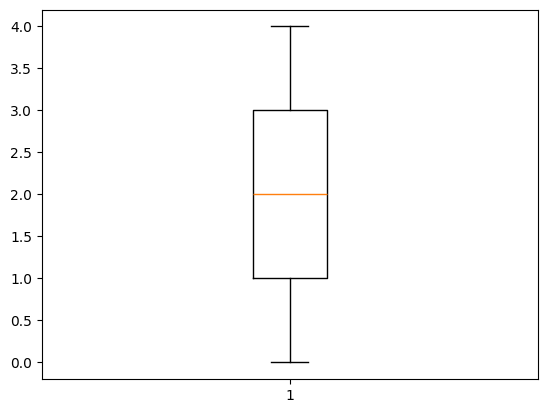

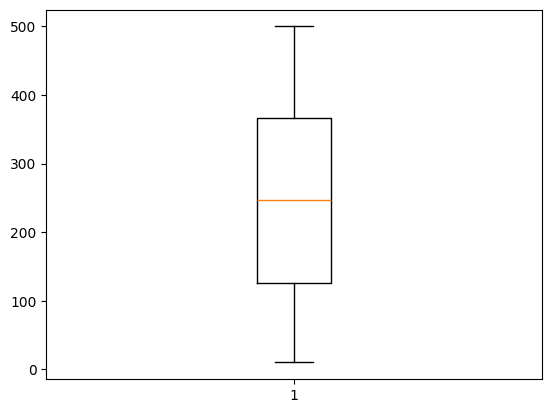

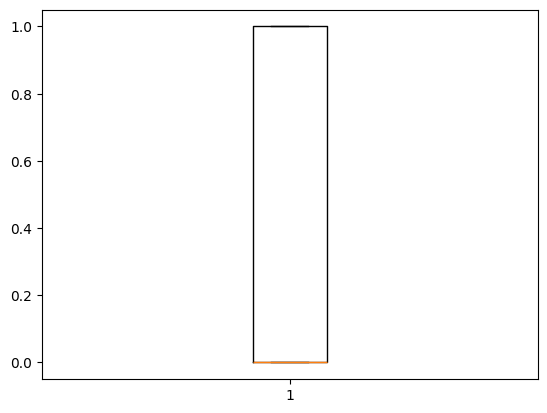

In [106]:
for i in lst:
  if df[i].dtype != 'object':
    plt.boxplot(df[i])
    plt.show()


In [107]:
df.describe()

,PassengerId,Pclass,Age,SibSp,Parch,Fare,Survived
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,1.964000,38.458000,2.032000,2.005000,247.968650,0.492000
std,288.819436,0.820596,23.103723,1.424431,1.410306,139.301211,0.500186
min,1.000000,1.000000,1.000000,0.000000,0.000000,10.020000,0.000000
25%,250.750000,1.000000,19.000000,1.000000,1.000000,126.295000,0.000000
50%,500.500000,2.000000,36.500000,2.000000,2.000000,246.500000,0.000000
75%,750.250000,3.000000,59.000000,3.000000,3.000000,365.662500,1.000000
max,1000.000000,3.000000,79.000000,4.000000,4.000000,499.780000,1.000000


In [108]:
df['Sex'].value_counts()

,count
Sex,
male,527
female,473


In [109]:
df['Embarked'].value_counts()

,count
Embarked,
Q,362
C,328
S,310


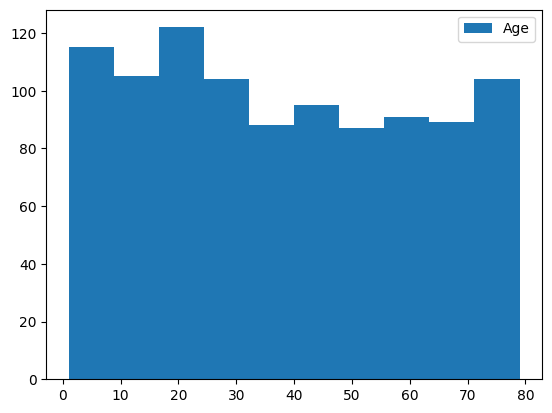

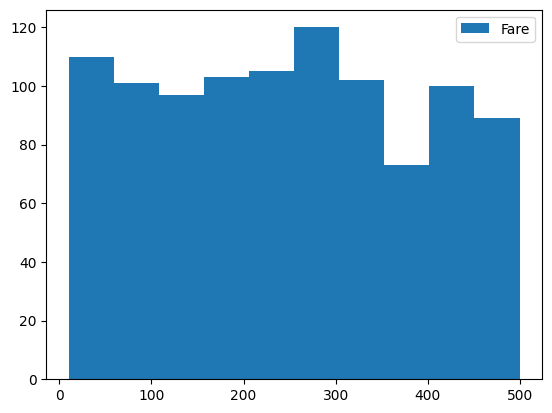

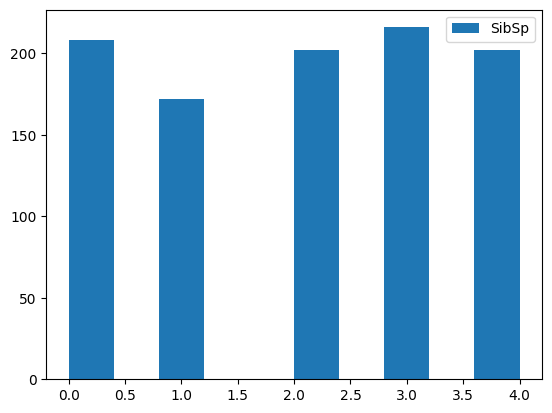

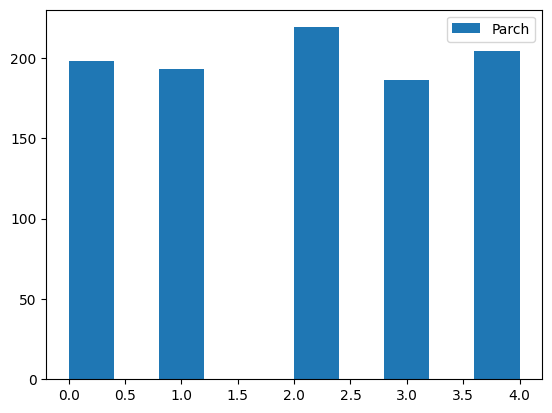

In [110]:
cols= ['Age','Fare','SibSp','Parch']
for i in cols:
  plt.hist(df[i],label=i)
  plt.legend()
  plt.show()


In [111]:
df = df.drop(columns=['Ticket','Name','PassengerId'])

In [112]:
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,male,17,4,2,144.08,Q,1
1,1,male,60,2,2,249.04,S,0
2,3,male,64,0,0,50.31,Q,1
3,3,male,35,4,0,235.20,C,1
4,1,female,70,0,3,160.17,C,1
...,...,...,...,...,...,...,...,...
995,2,male,69,2,3,19.87,Q,1
996,2,female,61,4,4,85.35,C,0
997,3,male,10,4,1,444.22,C,0
998,3,male,50,3,2,234.67,S,1


In [113]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
Le= LabelEncoder()
df['Sex'] = Le.fit_transform(df['Sex'])
df['Embarked'] = Le.fit_transform(df['Embarked'])
RF = RandomForestClassifier()

In [114]:
df

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,Survived
0,3,1,17,4,2,144.08,1,1
1,1,1,60,2,2,249.04,2,0
2,3,1,64,0,0,50.31,1,1
3,3,1,35,4,0,235.20,0,1
4,1,0,70,0,3,160.17,0,1
...,...,...,...,...,...,...,...,...
995,2,1,69,2,3,19.87,1,1
996,2,0,61,4,4,85.35,0,0
997,3,1,10,4,1,444.22,0,0
998,3,1,50,3,2,234.67,2,1


In [115]:
x = df.drop(columns=['Survived'])

In [116]:
x

,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked
0,3,1,17,4,2,144.08,1
1,1,1,60,2,2,249.04,2
2,3,1,64,0,0,50.31,1
3,3,1,35,4,0,235.20,0
4,1,0,70,0,3,160.17,0
...,...,...,...,...,...,...,...
995,2,1,69,2,3,19.87,1
996,2,0,61,4,4,85.35,0
997,3,1,10,4,1,444.22,0
998,3,1,50,3,2,234.67,2


In [117]:
y = df['Survived']

In [118]:
y

,Survived
0,1
1,0
2,1
3,1
4,1
...,...
995,1
996,0
997,0
998,1


In [119]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2)

In [120]:
RF = RF.fit(x_train,y_train)

In [121]:
y_pred =  RF.predict(x_test)

In [122]:
y_pred

array([0, 1, 0, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 1, 1, 1, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 1, 1, 0, 0, 1,
       1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1,
       0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0,
       1, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 1, 0, 1,
       0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 1,
       1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 1,
       0, 1])

In [123]:
from sklearn.metrics import*

In [124]:
accuracy_score(y_test,y_pred)

0.47

In [125]:
confusion_matrix(y_test,y_pred)

array([[49, 62],
       [44, 45]])

In [126]:
f1_score(y_test,y_pred)

0.45918367346938777

In [128]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

GridSearchCV

In [131]:
#Number of trees in random forest
n_estimators = [20,60,100,120]

#Number of features to xonsider at every split
max_features = [0.2,0.6,1.0]

#Maximum number of levels in tree
max_depth = [2,8,None]

#Number of samples
max_samples = [0.5,0.75,1.0]

In [132]:
param_grid = {'n_estimators':n_estimators,
              'max_features': max_features,
              'max_depth':max_depth,
              'max_samples':max_samples
              }

In [134]:
from sklearn.model_selection import GridSearchCV

rf_grid = GridSearchCV(estimator = RF,
                       param_grid = param_grid,
                       cv = 5,
                       verbose = 2,
                       n_jobs = -1)

In [135]:
rf_grid.fit(x_train,y_train)

Fitting 5 folds for each of 108 candidates, totalling 540 fits


GridSearchCV(cv=5, estimator=RandomForestClassifier(), n_jobs=-1,
             param_grid={'max_depth': [2, 8, None],
                         'max_features': [0.2, 0.6, 1.0],
                         'max_samples': [0.5, 0.75, 1.0],
                         'n_estimators': [20, 60, 100, 120]},
             verbose=2)

In [136]:
rf_grid.best_params_

{'max_depth': 8, 'max_features': 1.0, 'max_samples': 1.0, 'n_estimators': 120}

In [137]:
rf_grid.best_score_

np.float64(0.5325)